In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
auto_analyse_address = 'full_run_260428.csv'
auto_analyse_df = pd.read_csv(auto_analyse_address)

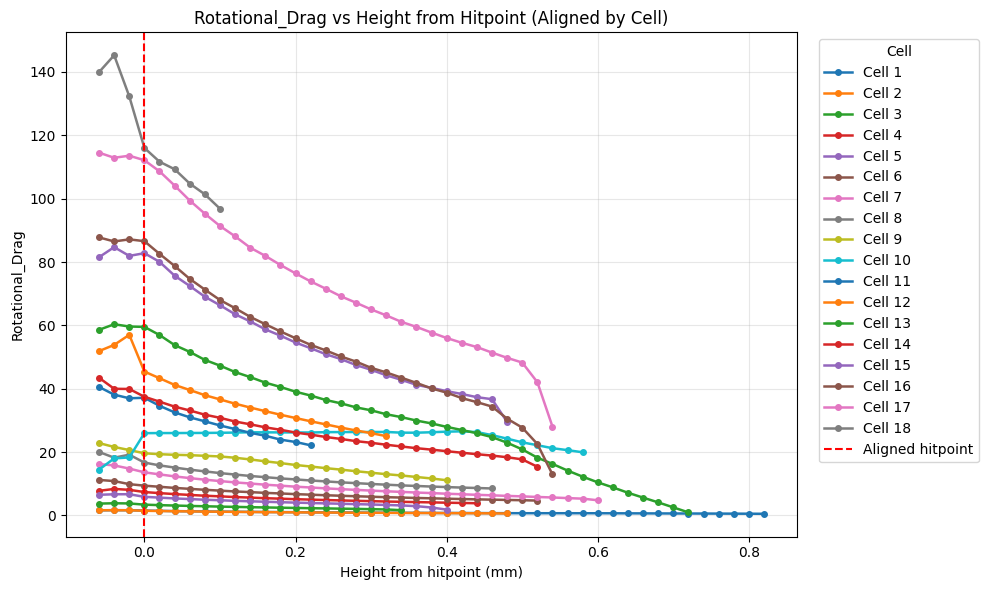

In [10]:
# Rotational_Drag vs height-from-hitpoint (one line per cell)
# Hitpoint definition per your note: the point BEFORE the last 3 points in each cell trace
plot_df = auto_analyse_df.copy()
if 'Z_Height_mm' not in plot_df.columns and 'Z_Hegiht_mm' in plot_df.columns:
    plot_df = plot_df.rename(columns={'Z_Hegiht_mm': 'Z_Height_mm'})

required_cols = {'cell', 'Z_Height_mm', 'Rotational_Drag'}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

label_col = 'Cell_Label' if 'Cell_Label' in plot_df.columns else None
cols_to_keep = ['cell', 'Z_Height_mm', 'Rotational_Drag'] + ([label_col] if label_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=['cell', 'Z_Height_mm', 'Rotational_Drag'])

plt.figure(figsize=(10, 6))
for cell_id, cell_df in plot_df.groupby('cell'):
    cell_df = cell_df.sort_values('Z_Height_mm').reset_index(drop=True)

    # Need at least 4 points so index 3 (point after first 3) exists
    if len(cell_df) < 4:
        print(f"Skipping Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    hit_idx = 3
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']

    # Shift x-axis so hitpoint is at 0 mm
    # Assumption requested: 1 Z-height unit == 1 mm
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    legend_label = f"Cell {int(cell_id)} - {cell_label}" if cell_label else f"Cell {int(cell_id)}"

    plt.plot(
        x_from_hit_mm,
        cell_df['Rotational_Drag'],
        marker='o',
        linewidth=1.8,
        markersize=4,
        label=legend_label
    )

# Aligned hitpoint marker (shared after shift)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Aligned hitpoint')

plt.xlabel('Height from hitpoint (mm)')
plt.ylabel('Rotational_Drag')
plt.title('Rotational_Drag vs Height from Hitpoint (Aligned by Cell)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cell', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()